# 02 — Modelos Supervisados Globales (PreTec21 → Tec21)
## Evaluación cross-régimen · Equipo 7

Entrena Regresión Logística, Random Forest y XGBoost en PreTec21 y evalúa en Tec21 (cross-regime). Incluye búsqueda de hiperparámetros, validación cruzada, curvas de aprendizaje, matrices de confusión y curvas ROC/PR.

## 1. Setup e Importaciones

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import time, os
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine as cosine_dist

# Clustering
from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score, davies_bouldin_score
from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.impute           import SimpleImputer

# Modelos supervisados
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import (
    StratifiedKFold, cross_validate, train_test_split
)
from sklearn.metrics          import (
    roc_auc_score, recall_score, f1_score, precision_score,
    roc_curve, precision_recall_curve
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(' XGBoost disponible:', xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print(' XGBoost no disponible')

try:
    import shap
    SHAP_AVAILABLE = True
    print(' SHAP disponible:', shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print(' SHAP no disponible')

SEED = 42
np.random.seed(SEED)
print('\n Librerías cargadas')

✓ XGBoost disponible: 3.2.0
✓ SHAP disponible: 0.51.0

✓ Librerías cargadas


## 2. Configuración

In [2]:
DATASET_MODE   = 'imputed'
DATA_DIR       = Path('../data')
IMG_DIR        = Path('../results/figures'); IMG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR      = Path('../results/tables');  TABLE_DIR.mkdir(parents=True, exist_ok=True)

PRETEC21_GENS  = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEC21_GENS     = ['AD19', 'AD20']
TARGET         = 'retention'

K_CLUSTERS     = 4
MIN_SILHOUETTE = 0.30
MAX_DB         = 1.50
MIN_AUC        = 0.60

# Umbral de distancia coseno para match de clusters
# < 0.15 → match alto | 0.15-0.35 → match parcial | > 0.35 → sin match
MATCH_HIGH     = 0.15
MATCH_PARTIAL  = 0.35

print(f'K_CLUSTERS    : {K_CLUSTERS}')
print(f'PreTec21 gens : {PRETEC21_GENS}')
print(f'Tec21 gens    : {TEC21_GENS}')
print(f'NOTA: En este notebook K-Means se entrena INDEPENDIENTEMENTE en cada régimen.')

K_CLUSTERS    : 4
PreTec21 gens : ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
Tec21 gens    : ['AD19', 'AD20']
NOTA: En este notebook K-Means se entrena INDEPENDIENTEMENTE en cada régimen.


## 3. Carga del Dataset

In [ ]:
csv_path = DATA_DIR / 'dataset_imputed.csv'
df_raw   = pd.read_csv(csv_path, low_memory=False)
print(f' {csv_path.name} cargado  ->  {df_raw.shape}')

print(f'\nDistribución por generación:')
print(df_raw['generation'].value_counts().sort_index().to_string())

print(f'\nDistribución target:')
counts = df_raw[TARGET].value_counts()
print(f'  Retuvo  (1): {counts.get(1,0):>6,}  ({counts.get(1,0)/len(df_raw)*100:.1f}%)')
print(f'  Desertó (0): {counts.get(0,0):>6,}  ({counts.get(0,0)/len(df_raw)*100:.1f}%)')

✓ dataset_imputed.csv cargado  →  (77517, 58)

Distribución por generación:
generation
AD14    10143
AD15    10041
AD16    10742
AD17    10788
AD18    11296
AD19    12199
AD20    12308

Distribución target:
  Retuvo  (1): 70,704  (91.2%)
  Desertó (0):  6,813  (8.8%)


## 4. Feature Engineering

In [4]:
from sklearn.preprocessing import LabelEncoder

def norm_admission_test(val):
    if pd.isna(val): return np.nan
    try:
        f = float(val)
        return max(0.0, (f - 400) / 1200.0) if f > 100 else f / 100.0
    except: return np.nan

EDU_ORD = {
    'No information': -1, 'MISSING': -1,
    'No degree': 0, 'Undergraduate degree': 1, 'Master degree': 2, 'PhD': 3,
}

df = df_raw.copy()
if 'level' in df.columns:
    df = df[df['level'] == 'Undergraduate'].copy()
    print(f'Filtrado nivel universitario: {len(df):,} registros')

DROP_COLS = [
    'student.id', 'level', 'average.first.period', 'failed.subject.first.period',
    'dropped.subject.first.period', 'dropout.semester', 'program', 'id.school.origin',
    'scholarship.type', 'school.cost', 'parents.exatec', 'father.exatec', 'mother.exatec',
    'father.education.complete', 'father.education.summary',
    'mother.education.complete', 'mother.education.summary',
    'scholarship.perc', 'loan.perc', 'educational.model',
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# ── admission_test_norm ───────────────────────────────────────────────────
if 'admission.test' in df.columns:
    df['admission_test_norm'] = df['admission.test'].apply(norm_admission_test)
    df.drop(columns=['admission.test'], inplace=True)
if 'admission_test_norm' not in df.columns:
    df['admission_test_norm'] = np.nan
df['admission_test_norm'].fillna(df['admission_test_norm'].median(), inplace=True)

# ── first_gen_enc ─────────────────────────────────────────────────────────
def enc_first_gen(v):
    s = str(v).strip() if pd.notna(v) else ''
    return 1 if s == 'Yes' else (0 if s == 'No' else -1)
if 'first.generation' in df.columns:
    df['first_gen_enc'] = df['first.generation'].apply(enc_first_gen)
    df.drop(columns=['first.generation'], inplace=True)
elif 'first_gen_enc' not in df.columns:
    df['first_gen_enc'] = -1

# ── educ_padres_max ───────────────────────────────────────────────────────
if 'max.degree.parents' in df.columns:
    df['educ_padres_max'] = df['max.degree.parents'].map(EDU_ORD).fillna(-1).astype(int)
    df.drop(columns=['max.degree.parents'], inplace=True)
elif 'educ_padres_max' not in df.columns:
    df['educ_padres_max'] = -1

# ── apoyo_financiero ──────────────────────────────────────────────────────
if 'total.scholarship.loan' in df.columns:
    df.rename(columns={'total.scholarship.loan': 'apoyo_financiero'}, inplace=True)
elif 'apoyo_financiero' not in df.columns:
    df['apoyo_financiero'] = 0.0

# ── has_extracurriculars ──────────────────────────────────────────────────
if 'has_extracurriculars' not in df.columns:
    df['has_extracurriculars'] = df['has_life_activities'].copy() if 'has_life_activities' in df.columns else 0

ACTIVITY_COLS = ['physical.education','cultural.diffusion','student.society',
                 'total.life.activities','athletic.sports','art.culture',
                 'student.society.leadership','life.work.mentoring','wellness.activities']
df.drop(columns=[c for c in ACTIVITY_COLS + ['has_life_activities'] if c in df.columns], inplace=True)

# ── variables demográficas y socioeconómicas ──────────────────────────────
if 'gender' in df.columns:
    df['is_male'] = df['gender'].map({'Male':1,'Female':0}).fillna(0).astype(int)
    df.drop(columns=['gender'], inplace=True)
elif 'is_male' not in df.columns:
    df['is_male'] = 0

if 'tec.no.tec' in df.columns:
    df['estuvo_prepa_tec'] = df['tec.no.tec'].map({'TEC':1,'NO TEC':0}).fillna(0).astype(int)
    df.drop(columns=['tec.no.tec'], inplace=True)
elif 'estuvo_prepa_tec' not in df.columns:
    df['estuvo_prepa_tec'] = 0

if 'socioeconomic.level' in df.columns:
    df['socioec_enc'] = df['socioeconomic.level'].map(
        {**{'No information':0,'MISSING':0},**{f'Level {i}':i for i in range(1,8)}}).fillna(0).astype(int)
    df.drop(columns=['socioeconomic.level'], inplace=True)
elif 'socioec_enc' not in df.columns:
    df['socioec_enc'] = 0

if 'social.lag' in df.columns:
    df['social_lag_enc'] = df['social.lag'].map(
        {'No information':0,'MISSING':0,'Low':1,'Medium':2,'High':3}).fillna(0).astype(int)
    df.drop(columns=['social.lag'], inplace=True)
elif 'social_lag_enc' not in df.columns:
    df['social_lag_enc'] = 0

if 'school' in df.columns:
    le_school = LabelEncoder()
    df['school_enc'] = le_school.fit_transform(df['school'].fillna('Unknown').astype(str))
    df.drop(columns=['school'], inplace=True)
elif 'school_enc' not in df.columns:
    df['school_enc'] = 0

if 'region' in df.columns:
    le_region = LabelEncoder()
    df['region_enc'] = le_region.fit_transform(df['region'].fillna('Unknown').astype(str))
    df.drop(columns=['region'], inplace=True)
elif 'region_enc' not in df.columns:
    df['region_enc'] = 0

if 'foreign' in df.columns:
    foreign_dummies = pd.get_dummies(df['foreign'], prefix='foreign', drop_first=True, dtype=int)
    df = pd.concat([df, foreign_dummies], axis=1)
    df.drop(columns=['foreign'], inplace=True)

df.drop(columns=[c for c in ['zone.type'] if c in df.columns], inplace=True)

print(f'\n✓ Feature engineering completado. Shape: {df.shape}')

Filtrado nivel universitario: 77,517 registros

✓ Feature engineering completado. Shape: (77517, 29)


## 5. Segmentación por Régimen

In [5]:
df_pre = df[df['generation'].isin(PRETEC21_GENS)].copy().reset_index(drop=True)
df_tec = df[df['generation'].isin(TEC21_GENS)].copy().reset_index(drop=True)

print(f'PreTec21 (AD14–AD18): {len(df_pre):,} estudiantes  |  Deserción: {(df_pre[TARGET]==0).mean()*100:.1f}%')
print(f'Tec21    (AD19–AD20): {len(df_tec):,} estudiantes  |  Deserción: {(df_tec[TARGET]==0).mean()*100:.1f}%')

PreTec21 (AD14–AD18): 53,010 estudiantes  |  Deserción: 8.8%
Tec21    (AD19–AD20): 24,507 estudiantes  |  Deserción: 8.7%


## 8. Features y Split para Modelos Supervisados

In [6]:
FEATURE_COLS_CANDIDATES = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'general.math.eval', 'online.test', 'FTE', 'apoyo_financiero',
    'has_extracurriculars', 'has_physical', 'has_cultural', 'has_social',
    'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'social_lag_enc',
    'age', 'is_male', 'estuvo_prepa_tec',
    'foreign_Yes: Foreigner', 'foreign_Yes: National',
    'school_enc', 'region_enc',
    'first_gen_present', 'parents_edu_present', 'took_admission_test',
    'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data',
]
EXCLUDE = {TARGET, 'cluster', 'generation', 'regime', 'educational.model'}
FEATURE_COLS = [c for c in FEATURE_COLS_CANDIDATES if c in df.columns and c not in EXCLUDE]
seen = set(); FEATURE_COLS = [c for c in FEATURE_COLS if c not in seen and not seen.add(c)]
print(f'Features para modelos supervisados ({len(FEATURE_COLS)}): {FEATURE_COLS}')

def make_split(df_regime, feature_cols, target=TARGET, seed=SEED):
    cols = [c for c in feature_cols if c in df_regime.columns]
    X    = df_regime[cols].values.astype(float)
    y    = df_regime[target].values.astype(int)
    imp  = SimpleImputer(strategy='median')
    X    = imp.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    return X_tr, X_te, y_tr, y_te, cols, imp

X_tr_pre, X_te_pre, y_tr_pre, y_te_pre, feat_pre, imp_pre = make_split(df_pre, FEATURE_COLS)
X_tr_tec, X_te_tec, y_tr_tec, y_te_tec, feat_tec, imp_tec = make_split(df_tec, FEATURE_COLS)
print(f'\nPreTec21  train: {X_tr_pre.shape}  test: {X_te_pre.shape}')
print(f'Tec21     train: {X_tr_tec.shape}  test: {X_te_tec.shape}')

Features para modelos supervisados (26): ['PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'general.math.eval', 'online.test', 'FTE', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'social_lag_enc', 'age', 'is_male', 'estuvo_prepa_tec', 'foreign_Yes: Foreigner', 'foreign_Yes: National', 'school_enc', 'region_enc', 'first_gen_present', 'parents_edu_present', 'took_admission_test', 'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data']

PreTec21  train: (42408, 26)  test: (10602, 26)
Tec21     train: (19605, 26)  test: (4902, 26)


## 9. Modelos Globales (PreTec21 → Tec21)

## 9a. Búsqueda de Hiperparámetros (RandomizedSearchCV)

Antes de entrenar los modelos finales se realiza una búsqueda aleatoria de
hiperparámetros sobre el conjunto de entrenamiento PreTec21 usando
`RandomizedSearchCV` con **5-fold StratifiedKFold** y métrica AUC-ROC.

**Espacio de búsqueda RF:** `n_estimators ∈ {100,200,300,400}`, `max_depth ∈ {4,6,8,10}`,
`min_samples_leaf ∈ {5,10,20}`, `max_features ∈ {'sqrt','log2'}`.

**Espacio de búsqueda XGB:** `n_estimators ∈ {100,200,300}`, `max_depth ∈ {3,5,7}`,
`learning_rate ∈ {0.01,0.05,0.1}`, `subsample ∈ {0.7,0.8,0.9}`,
`colsample_bytree ∈ {0.7,0.8,0.9}`.

El resultado (mejores parámetros) se guarda en `best_rf_params` / `best_xgb_params`
y se usa en las celdas de evaluación subsiguientes.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# ── Espacio de búsqueda RF ────────────────────────────────────────────────
rf_param_dist = {
    'n_estimators'   : [100, 200, 300, 400],
    'max_depth'      : [4, 6, 8, 10],
    'min_samples_leaf': [5, 10, 20],
    'max_features'   : ['sqrt', 'log2'],
}
rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist, n_iter=30, scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1, verbose=0
)
rf_search.fit(X_tr_pre, y_tr_pre)
best_rf_params = rf_search.best_params_
print(' Mejores parámetros RF:')
for k, v in sorted(best_rf_params.items()):
    print(f'    {k}: {v}')
print(f'  CV AUC (media): {rf_search.best_score_:.4f}')

# ── Espacio de búsqueda XGB ───────────────────────────────────────────────
if XGB_AVAILABLE:
    spw = float((y_tr_pre == 0).sum()) / max((y_tr_pre == 1).sum(), 1)
    xgb_param_dist = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [3, 5, 7],
        'learning_rate'   : [0.01, 0.05, 0.1],
        'subsample'       : [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
    }
    xgb_base = xgb.XGBClassifier(
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=SEED, n_jobs=-1, verbosity=0
    )
    xgb_search = RandomizedSearchCV(
        xgb_base, xgb_param_dist, n_iter=30, scoring='roc_auc',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        random_state=SEED, n_jobs=-1, verbose=0
    )
    xgb_search.fit(X_tr_pre, y_tr_pre)
    best_xgb_params = xgb_search.best_params_
    print('\n Mejores parámetros XGB:')
    for k, v in sorted(best_xgb_params.items()):
        print(f'    {k}: {v}')
    print(f'  CV AUC (media): {xgb_search.best_score_:.4f}')
else:
    best_xgb_params = {}
    print('XGBoost no disponible; se omite búsqueda.')


/Users/vicm/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Sem 8/Desarrollo de Aplicaciones Avanzadas/Claude-Project/Desarrollo de aplicaciones/ife-student-dropout-prediction/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vicm/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Sem 8/Desarrollo de Aplicaciones Avanzadas/Claude-Project/Desarrollo de aplicaciones/ife-student-dropout-prediction/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.

✓ Mejores parámetros RF:
    max_depth: 10
    max_features: log2
    min_samples_leaf: 20
    n_estimators: 300
  CV AUC (media): 0.6827

✓ Mejores parámetros XGB:
    colsample_bytree: 0.7
    learning_rate: 0.05
    max_depth: 3
    n_estimators: 200
    subsample: 0.7
  CV AUC (media): 0.6922


In [8]:
from sklearn.metrics import precision_recall_curve

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, feat_cols,
                   threshold=None, n_bootstrap=200, seed=SEED):
    model.fit(X_tr, y_tr)
    has_proba = hasattr(model, 'predict_proba')
    y_proba   = model.predict_proba(X_te)[:, 1] if has_proba else None
    if threshold is None and has_proba:
        skf_tmp = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
        oof = np.zeros(len(X_tr))
        for tr_i, va_i in skf_tmp.split(X_tr, y_tr):
            model.fit(X_tr[tr_i], y_tr[tr_i])
            oof[va_i] = model.predict_proba(X_tr[va_i])[:, 1]
        model.fit(X_tr, y_tr)
        # FIX: optimizar umbral para clase MINORITARIA (Desertor=0)
        # sklearn trata clase 1 como positiva por defecto; invertimos para clase 0
        oof_dropout = 1.0 - oof  # P(Desertor)
        prec_oof, rec_oof, thr_oof = precision_recall_curve(y_tr, oof_dropout, pos_label=0)
        f1_oof    = 2*prec_oof*rec_oof/(prec_oof+rec_oof+1e-8)
        thr_best  = float(thr_oof[np.argmax(f1_oof[:-1])])
        threshold = 1.0 - thr_best  # convertir de vuelta a threshold sobre P(Retenido)
    y_pred = (y_proba >= threshold).astype(int) if (threshold is not None and has_proba) \
             else model.predict(X_te)
    auc  = roc_auc_score(y_te, y_proba) if has_proba else 0.5
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, pos_label=0, zero_division=0)  # F1 para Desertor (clase minoritaria)
    rng  = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_te), len(y_te))
        if y_proba is not None and len(np.unique(y_te[idx])) > 1:
            aucs.append(roc_auc_score(y_te[idx], y_proba[idx]))
    ci_lo, ci_hi = (np.percentile(aucs, [2.5,97.5]) if aucs else (auc, auc))
    thr_str = f'{threshold:.2f}' if threshold is not None else 'N/A'
    result = dict(model=model_name, auc=auc, ci_lo=ci_lo, ci_hi=ci_hi,
                  recall=rec, precision=prec, f1=f1, threshold=threshold,
                  y_proba=y_proba, y_pred=y_pred, feat_cols=feat_cols)
    print(f'  {model_name:<28} AUC={auc:.3f} [{ci_lo:.3f},{ci_hi:.3f}]  '
          f'Recall={rec:.3f}  F1={f1:.3f}  thr={thr_str}')
    return result

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results_global = []

print('═══ Regresión Logística ═══')
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED, solver='lbfgs')
results_global.append(evaluate_model(lr, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec, 'LogisticRegression', feat_pre))

print('\n═══ Decision Tree ═══')
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED)
results_global.append(evaluate_model(dt, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec, 'DecisionTree', feat_pre))

print('\n═══ Random Forest (hiperparámetros optimizados) ═══')
# Usa best_rf_params de la búsqueda RandomizedSearchCV (celda 9a)
_rf_params = best_rf_params if 'best_rf_params' in dir() else {
    'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
rf = RandomForestClassifier(**_rf_params, class_weight='balanced',
                             random_state=SEED, n_jobs=-1)
results_global.append(evaluate_model(rf, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec, 'RandomForest', feat_pre))
rf_global = rf

if XGB_AVAILABLE:
    print('\n═══ XGBoost (hiperparámetros optimizados) ═══')
    spw = float((y_tr_pre == 0).sum()) / max((y_tr_pre == 1).sum(), 1)
    _xgb_params = best_xgb_params if 'best_xgb_params' in dir() else {
        'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05,
        'subsample': 0.8, 'colsample_bytree': 0.8}
    xgb_model = xgb.XGBClassifier(**_xgb_params, scale_pos_weight=spw,
                                   eval_metric='logloss', random_state=SEED,
                                   n_jobs=-1, verbosity=0)
    results_global.append(evaluate_model(xgb_model, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec, 'XGBoost', feat_pre))
    xgb_global = xgb_model
else:
    xgb_global = None

print('\n═══ Baseline: RF entrenado en Tec21 (self) ═══')
_rf_tec_params = best_rf_params if 'best_rf_params' in dir() else {
    'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
rf_tec_self = RandomForestClassifier(**_rf_tec_params, class_weight='balanced',
                                      random_state=SEED, n_jobs=-1)
res_tec_self = evaluate_model(rf_tec_self, X_tr_tec, X_te_tec, y_tr_tec, y_te_tec,
                               'RF_Tec21_self', feat_tec)
print('\n  (Comparar AUC RF_Tec21_self vs RandomForest cross-regime para medir degradación)')


═══ Regresión Logística ═══
  LogisticRegression           AUC=0.648 [0.622,0.670]  Recall=0.741  F1=0.212  thr=0.42

═══ Decision Tree ═══
  DecisionTree                 AUC=0.604 [0.576,0.630]  Recall=0.743  F1=0.190  thr=0.40

═══ Random Forest (hiperparámetros optimizados) ═══
  RandomForest                 AUC=0.655 [0.628,0.678]  Recall=0.816  F1=0.215  thr=0.45

═══ XGBoost (hiperparámetros optimizados) ═══
  XGBoost                      AUC=0.663 [0.635,0.686]  Recall=0.800  F1=0.243  thr=0.38

═══ Baseline: RF entrenado en Tec21 (self) ═══
  RF_Tec21_self                AUC=0.677 [0.653,0.698]  Recall=0.788  F1=0.237  thr=0.49

  (Comparar AUC RF_Tec21_self vs RandomForest cross-regime para medir degradación)


## 9b. Validación Cruzada y Curvas de Aprendizaje

Se reporta el AUC-ROC medio ± desviación estándar sobre **5-fold StratifiedKFold**
para cada modelo entrenado en PreTec21.  Las curvas de aprendizaje muestran el
gap entre desempeño en entrenamiento y validación a distintos tamaños de muestra.


In [9]:
from sklearn.model_selection import cross_val_score, learning_curve

# ── 5-fold CV sobre PreTec21 ─────────────────────────────────────────────
cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_models = [
    ('LogisticRegression', LogisticRegression(class_weight='balanced', max_iter=2000,
                                              random_state=SEED, solver='lbfgs')),
    ('DecisionTree',       DecisionTreeClassifier(max_depth=5, class_weight='balanced',
                                                   random_state=SEED)),
    ('RandomForest',       RandomForestClassifier(**best_rf_params,
                                                   class_weight='balanced',
                                                   random_state=SEED, n_jobs=-1)),
]
if XGB_AVAILABLE:
    spw = float((y_tr_pre == 0).sum()) / max((y_tr_pre == 1).sum(), 1)
    cv_models.append(('XGBoost', xgb.XGBClassifier(
        **best_xgb_params, scale_pos_weight=spw,
        eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0)))

print('═══ 5-fold CV AUC (PreTec21) ═══')
cv_results = {}
for name, mdl in cv_models:
    scores = cross_val_score(mdl, X_tr_pre, y_tr_pre, cv=cv_skf,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<28} {scores.mean():.4f} ± {scores.std():.4f}')

# ── Learning curve para Random Forest ────────────────────────────────────
rf_lc = RandomForestClassifier(**best_rf_params, class_weight='balanced',
                                random_state=SEED, n_jobs=-1)
train_sizes, train_scores, val_scores = learning_curve(
    rf_lc, X_tr_pre, y_tr_pre,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv_skf, scoring='roc_auc', n_jobs=-1
)
lc_train_mean = train_scores.mean(axis=1)
lc_train_std  = train_scores.std(axis=1)
lc_val_mean   = val_scores.mean(axis=1)
lc_val_std    = val_scores.std(axis=1)
print('\n═══ Learning Curve (RF) ═══')
print(f'  {"Tamaño":>8}  {"Train AUC":>10}  {"Val AUC":>10}  {"Gap":>8}')
for sz, tr, va in zip(train_sizes, lc_train_mean, lc_val_mean):
    print(f'  {int(sz):>8d}  {tr:>10.4f}  {va:>10.4f}  {tr-va:>8.4f}')


═══ 5-fold CV AUC (PreTec21) ═══
  LogisticRegression           0.6793 ± 0.0184
  DecisionTree                 0.6544 ± 0.0196
  RandomForest                 0.6827 ± 0.0180
  XGBoost                      0.6922 ± 0.0149


/Users/vicm/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Sem 8/Desarrollo de Aplicaciones Avanzadas/Claude-Project/Desarrollo de aplicaciones/ife-student-dropout-prediction/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vicm/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Sem 8/Desarrollo de Aplicaciones Avanzadas/Claude-Project/Desarrollo de aplicaciones/ife-student-dropout-prediction/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.


═══ Learning Curve (RF) ═══
    Tamaño   Train AUC     Val AUC       Gap
      3392      0.8817      0.6592    0.2225
      7754      0.8554      0.6702    0.1852
     12116      0.8341      0.6718    0.1622
     16478      0.8214      0.6777    0.1437
     20840      0.8125      0.6777    0.1349
     25202      0.8019      0.6810    0.1209
     29564      0.7949      0.6821    0.1128
     33926      0.7885      0.6826    0.1058


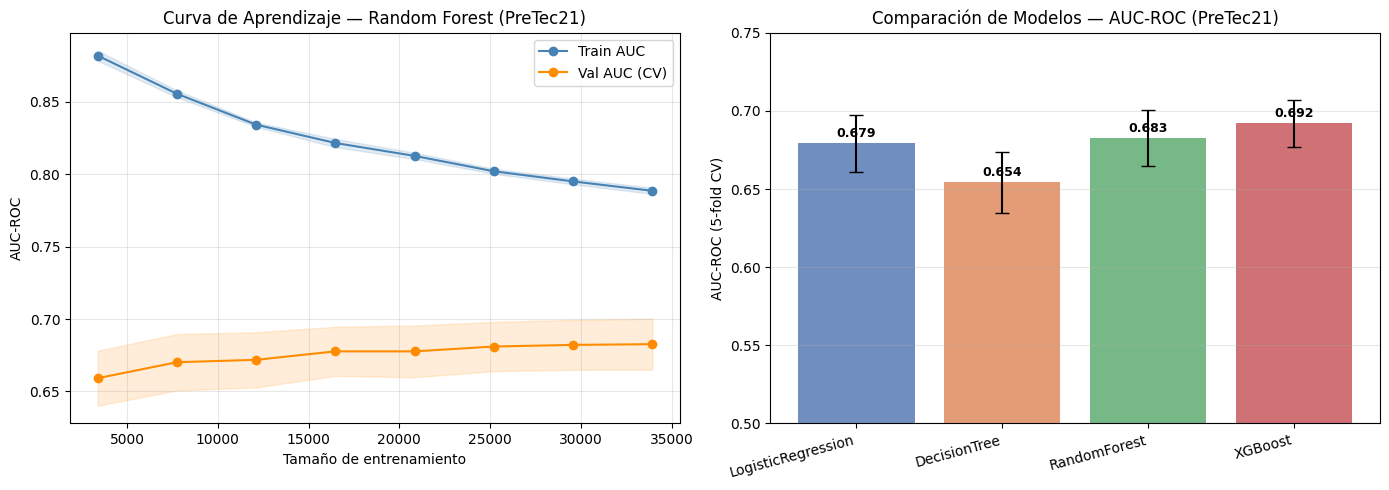

✓ Guardado: ../results/figures/learning_curve_cv.png


In [ ]:
# ── Plot curva de aprendizaje ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Learning curve
ax = axes[0]
ax.fill_between(train_sizes, lc_train_mean - lc_train_std,
                lc_train_mean + lc_train_std, alpha=0.15, color='steelblue')
ax.fill_between(train_sizes, lc_val_mean - lc_val_std,
                lc_val_mean + lc_val_std, alpha=0.15, color='darkorange')
ax.plot(train_sizes, lc_train_mean, 'o-', color='steelblue', label='Train AUC')
ax.plot(train_sizes, lc_val_mean,   'o-', color='darkorange', label='Val AUC (CV)')
ax.set_xlabel('Tamaño de entrenamiento'); ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de Aprendizaje — Random Forest (PreTec21)')
ax.legend(); ax.grid(True, alpha=0.3)

# Right: CV AUC comparison bar chart
ax2 = axes[1]
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
colors = ['#4C72B0','#DD8452','#55A868','#C44E52'][:len(names)]
bars = ax2.bar(names, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
ax2.set_ylim(0.5, 0.75)
ax2.set_ylabel('AUC-ROC (5-fold CV)')
ax2.set_title('Comparación de Modelos — AUC-ROC (PreTec21)')
ax2.set_xticklabels(names, rotation=15, ha='right')
for bar, m in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, m + 0.002, f'{m:.3f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(IMG_DIR / 'learning_curve_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Guardado: {IMG_DIR}/learning_curve_cv.png')


## 9c. Matrices de Confusión y Curvas ROC/PR

Visualización de matrices de confusión normalizadas y curvas ROC + Precision-Recall
para todos los modelos globales evaluados en Tec21 (cross-regime).


In [11]:
from sklearn.metrics import (ConfusionMatrixDisplay, confusion_matrix,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)

# ── Re-entrenar modelos con mejores hiperparámetros para tener y_proba ────
final_models = {}
results_final = []

print('═══ Entrenando modelos finales (mejores hiperparámetros) ═══')
# Logistic Regression
lr_final = LogisticRegression(class_weight='balanced', max_iter=2000,
                               random_state=SEED, solver='lbfgs')
res_lr = evaluate_model(lr_final, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                        'LogisticRegression', feat_pre)
results_final.append(res_lr); final_models['LogisticRegression'] = lr_final

# Decision Tree
dt_final = DecisionTreeClassifier(max_depth=5, class_weight='balanced',
                                   random_state=SEED)
res_dt = evaluate_model(dt_final, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                        'DecisionTree', feat_pre)
results_final.append(res_dt); final_models['DecisionTree'] = dt_final

# Random Forest (tuned)
rf_final = RandomForestClassifier(**best_rf_params, class_weight='balanced',
                                   random_state=SEED, n_jobs=-1)
res_rf = evaluate_model(rf_final, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                        'RandomForest', feat_pre)
results_final.append(res_rf); final_models['RandomForest'] = rf_final

# XGBoost (tuned)
if XGB_AVAILABLE:
    spw = float((y_tr_pre == 0).sum()) / max((y_tr_pre == 1).sum(), 1)
    xgb_final = xgb.XGBClassifier(**best_xgb_params, scale_pos_weight=spw,
                                    eval_metric='logloss', random_state=SEED,
                                    n_jobs=-1, verbosity=0)
    res_xgb = evaluate_model(xgb_final, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                              'XGBoost', feat_pre)
    results_final.append(res_xgb); final_models['XGBoost'] = xgb_final


═══ Entrenando modelos finales (mejores hiperparámetros) ═══
  LogisticRegression           AUC=0.648 [0.622,0.670]  Recall=0.741  F1=0.212  thr=0.42
  DecisionTree                 AUC=0.604 [0.576,0.630]  Recall=0.743  F1=0.190  thr=0.40
  RandomForest                 AUC=0.655 [0.628,0.678]  Recall=0.816  F1=0.215  thr=0.45
  XGBoost                      AUC=0.663 [0.635,0.686]  Recall=0.800  F1=0.243  thr=0.38


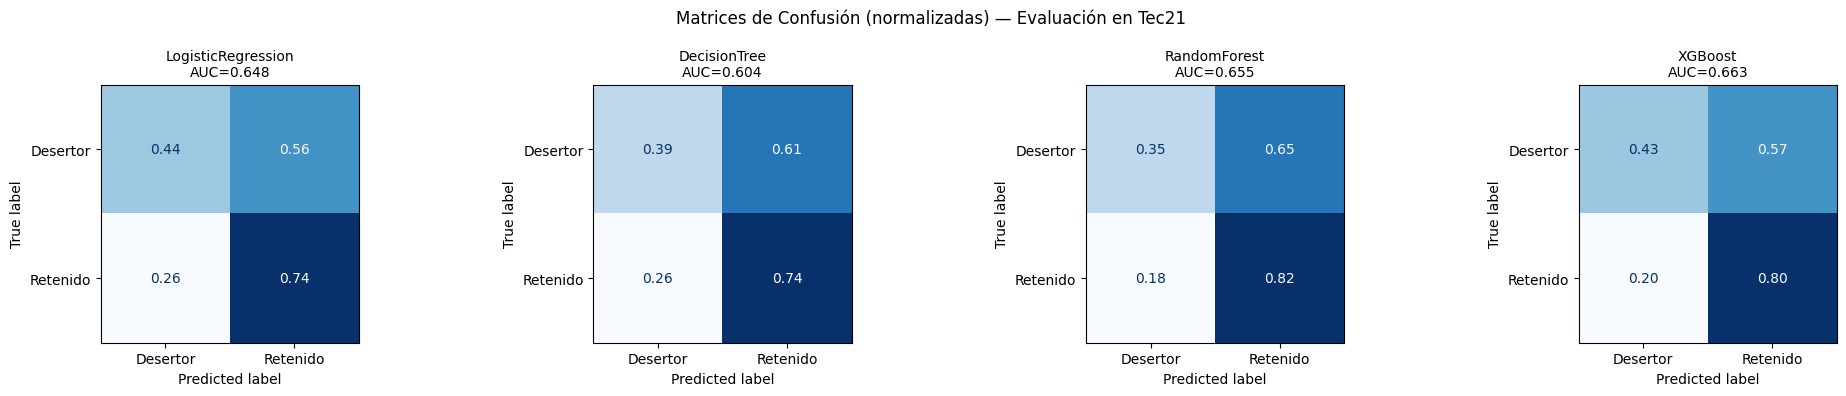

✓ Guardado: ../results/figures/confusion_matrices.png


In [ ]:
# ── Matrices de Confusión normalizadas ───────────────────────────────────
n_models = len(results_final)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))
if n_models == 1: axes = [axes]

for ax, res in zip(axes, results_final):
    cm = confusion_matrix(y_te_tec, res['y_pred'], normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Desertor', 'Retenido'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{res["model"]}\nAUC={res["auc"]:.3f}', fontsize=10)

fig.suptitle('Matrices de Confusión (normalizadas) — Evaluación en Tec21', fontsize=12)
plt.tight_layout()
plt.savefig(IMG_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Guardado: {IMG_DIR}/confusion_matrices.png')


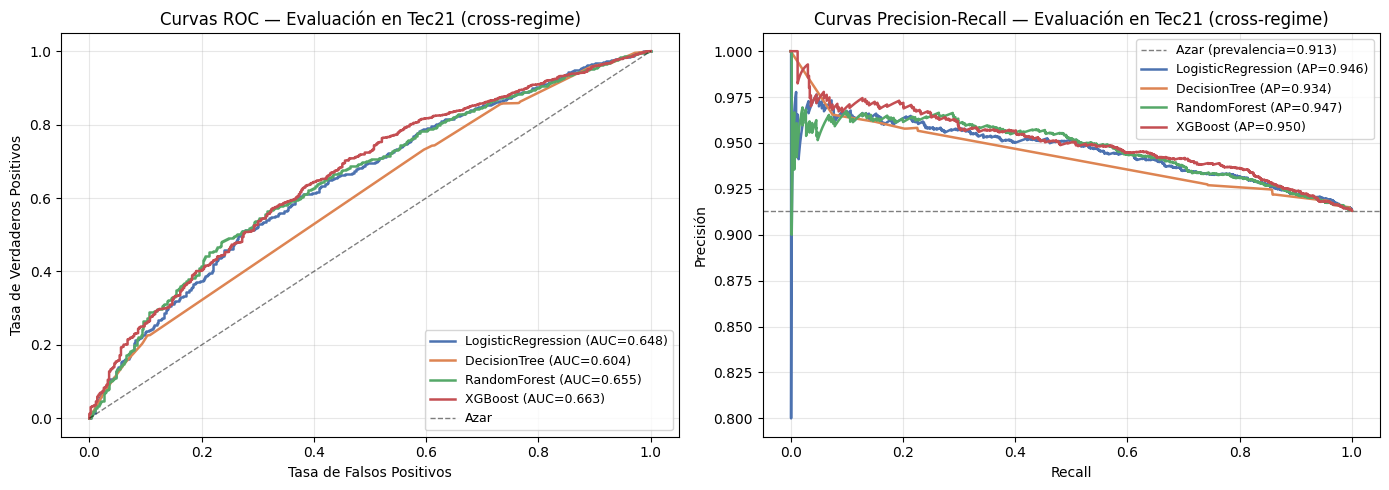

✓ Guardado: ../results/figures/roc_pr_curves.png


In [ ]:
# ── Curvas ROC y Precision-Recall ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#9467BD']

# ROC curves
ax = axes[0]
for i, res in enumerate(results_final):
    if res['y_proba'] is None: continue
    fpr, tpr, _ = roc_curve(y_te_tec, res['y_proba'])
    roc_auc_val  = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[i % len(colors)],
            label=f'{res["model"]} (AUC={roc_auc_val:.3f})', lw=1.8)
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Azar')
ax.set_xlabel('Tasa de Falsos Positivos'); ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Evaluación en Tec21 (cross-regime)')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)

# PR curves
ax2 = axes[1]
baseline_pr = y_te_tec.mean()
ax2.axhline(baseline_pr, color='k', linestyle='--', lw=1, alpha=0.5,
            label=f'Azar (prevalencia={baseline_pr:.3f})')
for i, res in enumerate(results_final):
    if res['y_proba'] is None: continue
    prec_c, rec_c, _ = precision_recall_curve(y_te_tec, res['y_proba'])
    ap_val = average_precision_score(y_te_tec, res['y_proba'])
    ax2.plot(rec_c, prec_c, color=colors[i % len(colors)],
             label=f'{res["model"]} (AP={ap_val:.3f})', lw=1.8)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precisión')
ax2.set_title('Curvas Precision-Recall — Evaluación en Tec21 (cross-regime)')
ax2.legend(loc='upper right', fontsize=9); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f' Guardado: {IMG_DIR}/roc_pr_curves.png')
